In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
import os
import urllib.request
import zipfile
import pickle
import joblib
import tensorflow as tf

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout, Bidirectional, Input,
    BatchNormalization, Flatten, Activation, Multiply,
    GlobalMaxPooling1D, Permute, RepeatVector
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')

# Download NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Set style
plt.style.use('ggplot')
sns.set_style('whitegrid')

print("  All imports successful!")
print(f"TensorFlow version: {tf.__version__}")

✅ All imports successful!
TensorFlow version: 2.20.0


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data Loading and Initial Exploration

In [2]:

data = pd.read_csv('train.txt', sep=';', header=None, names=['comment', 'emotion'])
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (16000, 2)


,comment,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


# Emotion Distribution Visualization

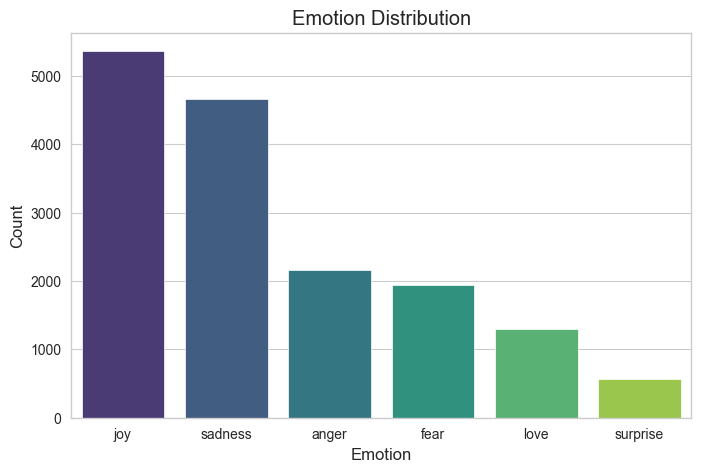

In [3]:
emotion_counts = data['emotion'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()

# Text Length Analysis

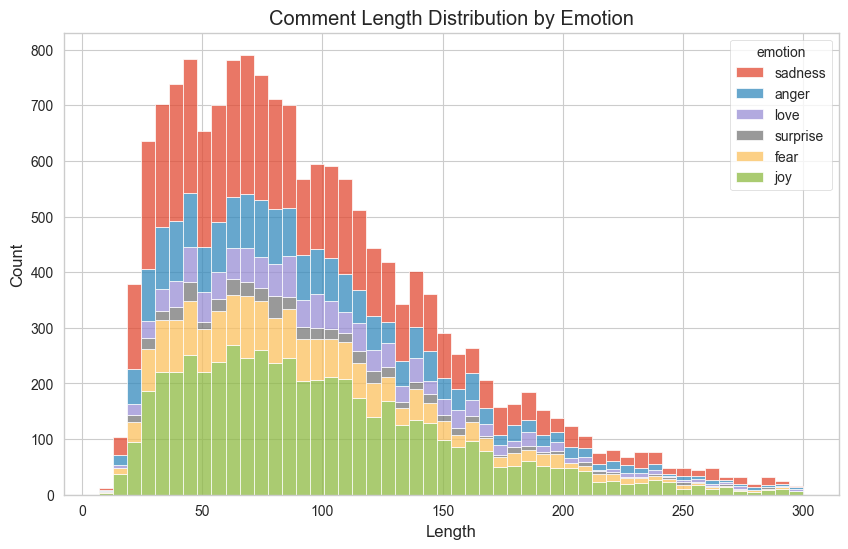

In [4]:
# Cell 4: Text Length Analysis

data['length'] = data['comment'].apply(len)
plt.figure(figsize=(10,6))
sns.histplot(data=data, x='length', hue='emotion', multiple='stack', bins=50)
plt.title('Comment Length Distribution by Emotion')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

# Check Missing Values and Duplicates

In [5]:
# Cell 5: Check Missing Values and Duplicates

print("Missing values:\n", data.isnull().sum())
print("\nDuplicates:", data.duplicated().sum())

Missing values:
 comment    0
emotion    0
length     0
dtype: int64

Duplicates: 1


# Text Preprocessing Function

In [6]:
# Cell 6: Text Preprocessing Function

stemmer = PorterStemmer()

def preprocess_text(text, stem=False):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    if stem:
        tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

# Apply preprocessing
data['clean_comment'] = data['comment'].apply(lambda x: preprocess_text(x, stem=False))

# Show example
print("Original:", data['comment'].iloc[0])
print("Cleaned:", data['clean_comment'].iloc[0])

Original: i didnt feel humiliated
Cleaned: didnt feel humiliated


# Train/Test Split

In [7]:
# Cell 7: Train/Test Split

X = data['clean_comment']
y = data['emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 12800, Testing samples: 3200


In [8]:
# TF-IDF Feature Extraction

In [9]:
# Cell 8: TF-IDF Feature Extraction

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (12800, 5000)


# Label Encoding

In [10]:
# Cell 9: Label Encoding

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

label_names = le.classes_
print("Classes:", label_names)

Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


# Traditional ML Models - Training and Evaluation

In [11]:
# Cell 10: Traditional ML Models

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial NB': MultinomialNB(),
    'SVM (linear)': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
conf_matrices = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_tfidf, y_train_enc)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test_enc, y_pred)
    results[name] = acc
    conf_matrices[name] = confusion_matrix(y_test_enc, y_pred)
    print(f"{name} accuracy: {acc:.4f}")
    print(classification_report(y_test_enc, y_pred, target_names=label_names))
    print("-" * 50)


Training Logistic Regression...
Logistic Regression accuracy: 0.8800
              precision    recall  f1-score   support

       anger       0.93      0.79      0.86       432
        fear       0.88      0.83      0.85       387
         joy       0.84      0.96      0.89      1072
        love       0.86      0.67      0.75       261
     sadness       0.91      0.95      0.93       933
    surprise       0.91      0.61      0.73       115

    accuracy                           0.88      3200
   macro avg       0.89      0.80      0.84      3200
weighted avg       0.88      0.88      0.88      3200

--------------------------------------------------

Training Multinomial NB...
Multinomial NB accuracy: 0.7869
              precision    recall  f1-score   support

       anger       0.95      0.62      0.75       432
        fear       0.89      0.64      0.75       387
         joy       0.72      0.98      0.83      1072
        love       0.98      0.23      0.37       261
     

# Confusion Matrices for ML Models

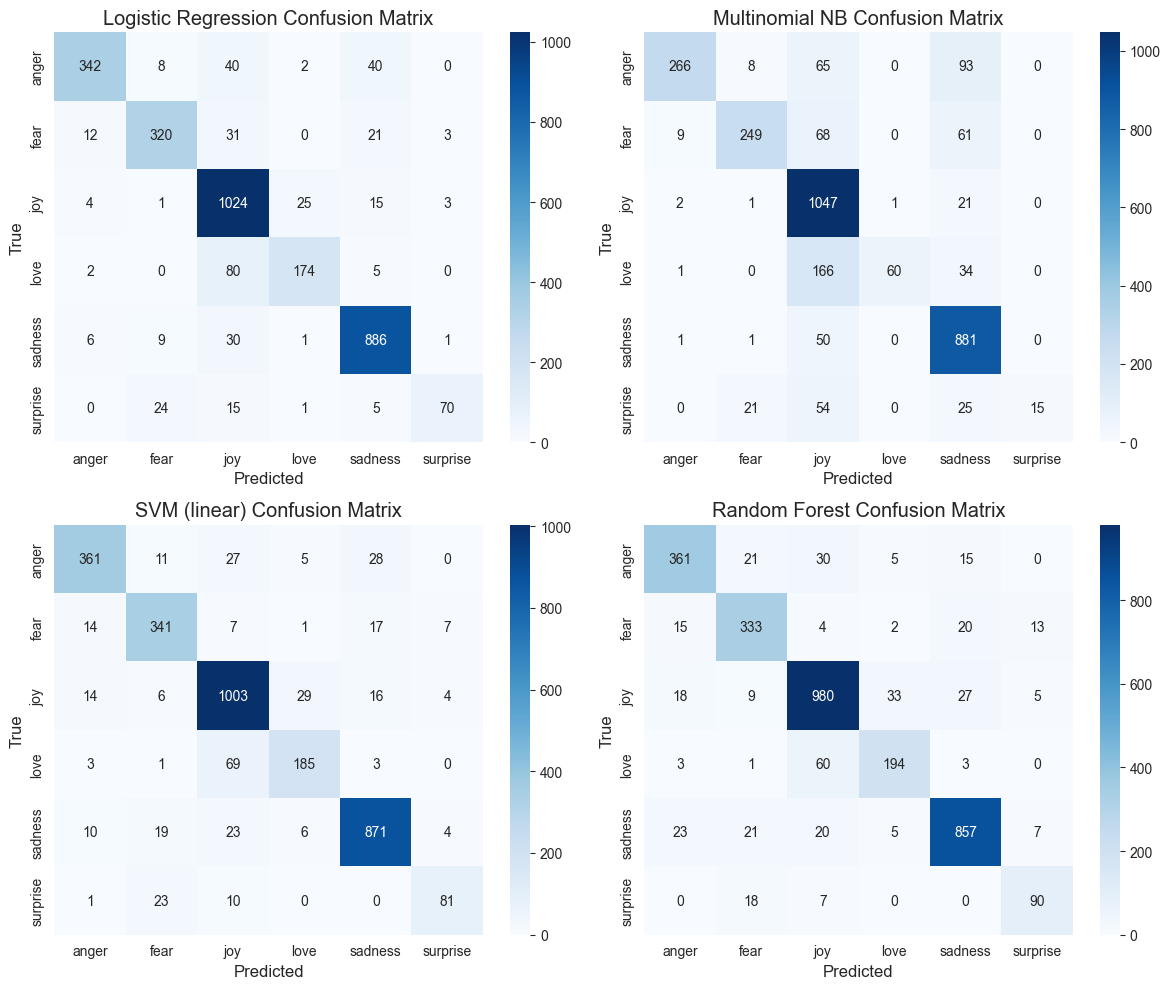

In [12]:
# Cell 11: Confusion Matrices for ML Models

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()
for i, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
plt.tight_layout()
plt.show()

# Basic LSTM - Tokenization and Padding

In [13]:
# Cell 12: Basic LSTM - Tokenization and Padding

tokenizer_basic = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer_basic.fit_on_texts(X_train)

X_train_seq = tokenizer_basic.texts_to_sequences(X_train)
X_test_seq = tokenizer_basic.texts_to_sequences(X_test)

# Determine max length (95th percentile)
max_len = int(np.percentile([len(seq) for seq in X_train_seq], 95))
print(f"Using max length: {max_len}")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# One-hot encode labels
y_train_onehot = to_categorical(y_train_enc, num_classes=len(label_names))
y_test_onehot = to_categorical(y_test_enc, num_classes=len(label_names))

Using max length: 20


# Basic LSTM - Model Building and Training

In [14]:
# Cell 13: Basic LSTM - Model Building and Training

basic_lstm = Sequential([
    Embedding(10000, 128, input_length=max_len),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(label_names), activation='softmax')
])
basic_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
basic_lstm.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_basic_lstm.keras', monitor='val_accuracy', save_best_only=True)

# Train
history_basic = basic_lstm.fit(
    X_train_pad, y_train_onehot,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Evaluate
test_loss, test_acc = basic_lstm.evaluate(X_test_pad, y_test_onehot, verbose=0)
print(f"\nBasic LSTM Test Accuracy: {test_acc:.4f}")
results['Basic LSTM'] = test_acc

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 24s 101ms/step - accuracy: 0.4627 - loss: 1.3681 - val_accuracy: 0.7359 - val_loss: 0.7569
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.8214 - loss: 0.5325 - val_accuracy: 0.8844 - val_loss: 0.3460
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - accuracy: 0.9308 - loss: 0.2346 - val_accuracy: 0.8883 - val_loss: 0.2992
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.9581 - loss: 0.1374 - val_accuracy: 0.9008 - val_loss: 0.3116
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.9682 - loss: 0.1085 - val_accuracy: 0.9008 - val_loss: 0.3699
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.9763 - loss: 0.0810 - val_accuracy: 0.8898 - val_loss: 0.3909

Basic LSTM Test Accuracy: 0.8875


# Download GloVe Embeddings

In [15]:

glove_path = 'glove.6B.300d.txt'
if not os.path.exists(glove_path):
    print("Downloading GloVe embeddings...")
    url = 'https://nlp.stanford.edu/data/glove.6B.zip'
    urllib.request.urlretrieve(url, 'glove.6B.zip')
    with zipfile.ZipFile('glove.6B.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Download complete.")
else:
    print("GloVe embeddings already downloaded.")

GloVe embeddings already downloaded.


# Improved LSTM - Parameters and Tokenization

In [16]:
# Cell 15: Improved LSTM - Parameters and Tokenization

MAX_WORDS = 20000
MAX_LEN = 120
EMBEDDING_DIM = 300
LSTM_UNITS = 128

# Tokenizer with larger vocabulary
tokenizer_glove = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_glove.fit_on_texts(X_train)

X_train_seq_glove = tokenizer_glove.texts_to_sequences(X_train)
X_test_seq_glove = tokenizer_glove.texts_to_sequences(X_test)

X_train_pad_glove = pad_sequences(X_train_seq_glove, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad_glove = pad_sequences(X_test_seq_glove, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Training data shape: {X_train_pad_glove.shape}")
print(f"Testing data shape: {X_test_pad_glove.shape}")

Training data shape: (12800, 120)
Testing data shape: (3200, 120)


# Load GloVe and Build Embedding Matrix

In [17]:
# Cell 16: Load GloVe and Build Embedding Matrix

# Load GloVe
embeddings_index = {}
with open('glove.6B.300d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} word vectors.")

# Build embedding matrix
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
for word, i in tokenizer_glove.word_index.items():
    if i < MAX_WORDS:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Loaded 400000 word vectors.
Embedding matrix shape: (20000, 300)


# Self-Attention Layer Definition

In [18]:
# Cell 17: Self-Attention Layer Definition

def attention_layer(inputs, return_weights=False):
    """
    Self-attention layer that works with any feature dimension.
    inputs: (batch, time_steps, features)
    """
    # Get the feature dimension from inputs
    feature_dim = inputs.shape[-1]
    
    # Compute attention scores
    attention = Dense(1, activation='tanh')(inputs)          # (batch, time_steps, 1)
    attention = Flatten()(attention)                        # (batch, time_steps)
    attention = Activation('softmax')(attention)            # (batch, time_steps)
    
    # Reshape attention weights to match feature dimension
    attention_weights = RepeatVector(feature_dim)(attention)  # (batch, features, time_steps)
    attention_weights = Permute((2, 1))(attention_weights)    # (batch, time_steps, features)
    
    # Apply attention weights
    weighted = Multiply()([inputs, attention_weights])       # (batch, time_steps, features)
    
    # Global max pooling
    pooled = GlobalMaxPooling1D()(weighted)                  # (batch, features)
    
    if return_weights:
        return pooled, attention
    return pooled

print("  Attention layer defined")

✅ Attention layer defined


# Build Improved LSTM Model

In [19]:
# Cell 18: Build Improved LSTM Model

def build_improved_lstm(learning_rate=0.001):
    """
    Build improved LSTM model with:
    - GloVe embeddings
    - Stacked Bidirectional LSTM layers
    - Self-attention mechanism
    - Batch normalization
    - L2 regularization
    """
    input_layer = Input(shape=(MAX_LEN,))
    
    # Embedding layer with GloVe weights
    embedding = Embedding(
        MAX_WORDS, EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True,
        name='embedding'
    )(input_layer)
    
    # First BiLSTM layer
    lstm1 = Bidirectional(
        LSTM(LSTM_UNITS, 
             return_sequences=True, 
             dropout=0.2, 
             recurrent_dropout=0.2,
             kernel_regularizer=l2(1e-4),
             name='bilstm1')
    )(embedding)
    
    # Batch normalization
    lstm1_norm = BatchNormalization()(lstm1)
    
    # Second BiLSTM layer
    lstm2 = Bidirectional(
        LSTM(LSTM_UNITS // 2,
             return_sequences=True, 
             dropout=0.2, 
             recurrent_dropout=0.2,
             kernel_regularizer=l2(1e-4),
             name='bilstm2')
    )(lstm1_norm)
    
    # Self-attention layer
    attended = attention_layer(lstm2)
    
    # Dense layers
    dense = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(attended)
    dense = BatchNormalization()(dense)
    dense = Dropout(0.5)(dense)
    
    dense2 = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(dense)
    dense2 = Dropout(0.3)(dense2)
    
    # Output layer
    output = Dense(len(label_names), activation='softmax', name='output')(dense2)
    
    model = Model(inputs=input_layer, outputs=output)
    
    # Compile with Adam optimizer
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer, 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )
    
    return model

# Build the model
print("Building improved LSTM model...")
improved_model = build_improved_lstm()
improved_model.summary()

Building improved LSTM model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 120)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 120, 300)          │       6,000,000 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 120, 256)          │         439,296 │ embedding[0][0]            │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 120, 256)          │           1,024 │ bidirectional_1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_2               │ (None, 120, 128)          │         164,352 │ batch_normalization[0][0]  │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 120, 1)            │             129 │ bidirectional_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 120)               │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 120)               │               0 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ repeat_vector (RepeatVector)  │ (None, 128, 120)          │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ permute (Permute)             │ (None, 120, 128)          │               0 │ repeat_vector[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 120, 128)          │               0 │ bidirectional_2[0][0],     │
│                               │                           │                 │ permute[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 128)               │               0 │ multiply[0][0]             │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 128)               │          16,512 │ global_max_pooling1d[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 128)               │             512 │ dense_3[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 6,630,471 (25.29 MB)

 Trainable params: 6,629,703 (25.29 MB)

 Non-trainable params: 768 (3.00 KB)

# Train Improved LSTM Model

In [20]:
# Cell 19: Train Improved LSTM Model

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=2, 
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_improved_lstm.keras',
    monitor='val_accuracy', 
    save_best_only=True,
    verbose=1
)

# Train
print("Training improved LSTM model...")
history_improved = improved_model.fit(
    X_train_pad_glove, 
    y_train_onehot,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Evaluate
test_loss_imp, test_acc_imp = improved_model.evaluate(
    X_test_pad_glove, 
    y_test_onehot, 
    verbose=0
)
print(f"\n{'='*50}")
print(f"Improved LSTM Test Accuracy: {test_acc_imp:.4f}")
print(f"Improved LSTM Test Loss: {test_loss_imp:.4f}")
print(f"{'='*50}")

# Add to results
results['Improved LSTM'] = test_acc_imp

Training improved LSTM model...
Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 337s/step - accuracy: 0.4347 - loss: 1.6227  
Epoch 1: val_accuracy improved from None to 0.60156, saving model to best_improved_lstm.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 60381s 337s/step - accuracy: 0.5604 - loss: 1.3495 - val_accuracy: 0.6016 - val_loss: 1.7039 - learning_rate: 0.0010
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8286 - loss: 0.6524
Epoch 2: val_accuracy improved from 0.60156 to 0.61328, saving model to best_improved_lstm.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 416s 2s/step - accuracy: 0.8589 - loss: 0.5631 - val_accuracy: 0.6133 - val_loss: 1.4320 - learning_rate: 0.0010
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9262 - loss: 0.3637
Epoch 3: val_accuracy improved from 0.61328 to 0.93359, saving model to best_improved_lstm.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.9232 - loss: 0.3663 - val_accuracy: 0.9336 - val_loss: 0.3578 - learning_rate

# Plot Training History

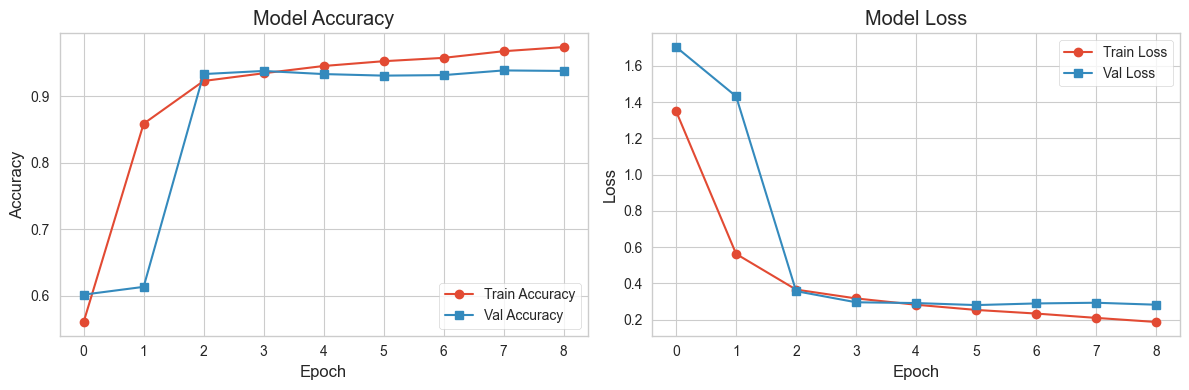

In [21]:
# Cell 20: Plot Training History

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history_improved.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history_improved.history['val_accuracy'], label='Val Accuracy', marker='s')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history_improved.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history_improved.history['val_loss'], label='Val Loss', marker='s')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix for Improved LSTM

100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step

CLASSIFICATION REPORT - Improved LSTM
              precision    recall  f1-score   support

       anger       0.94      0.94      0.94       432
        fear       0.88      0.93      0.90       387
         joy       0.97      0.91      0.94      1072
        love       0.77      0.89      0.82       261
     sadness       0.97      0.97      0.97       933
    surprise       0.81      0.83      0.82       115

    accuracy                           0.93      3200
   macro avg       0.89      0.91      0.90      3200
weighted avg       0.93      0.93      0.93      3200



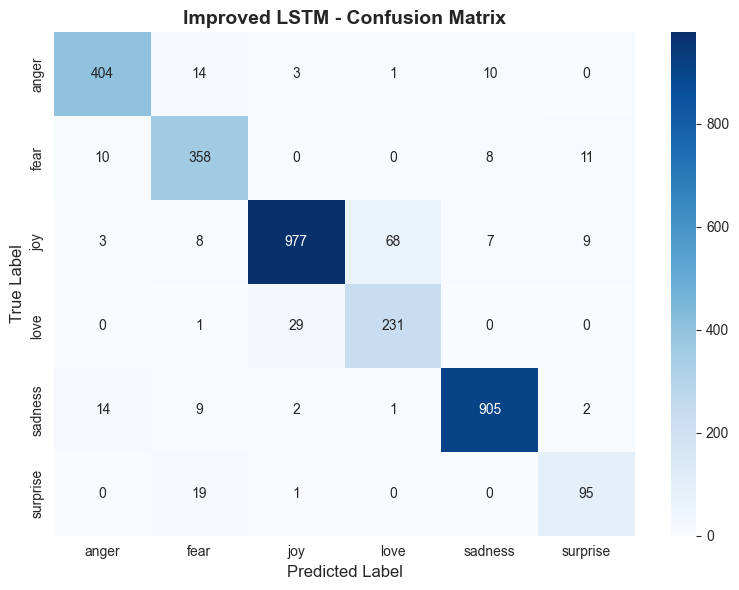

In [22]:
# Cell 21: Confusion Matrix for Improved LSTM

from sklearn.metrics import classification_report, confusion_matrix

# Predict on test set
y_pred_probs = improved_model.predict(X_test_pad_glove)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("\n" + "="*50)
print("CLASSIFICATION REPORT - Improved LSTM")
print("="*50)
print(classification_report(y_test_enc, y_pred, target_names=label_names))

# Confusion matrix
cm_lstm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Improved LSTM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Final Results Comparison


SUMMARY OF ALL MODELS
              Model  Accuracy
      Improved LSTM  0.928125
       SVM (linear)  0.888125
         Basic LSTM  0.887500
Logistic Regression  0.880000
      Random Forest  0.879687
     Multinomial NB  0.786875

🏆 Best Model: Improved LSTM
   Accuracy: 0.9281 (92.81%)


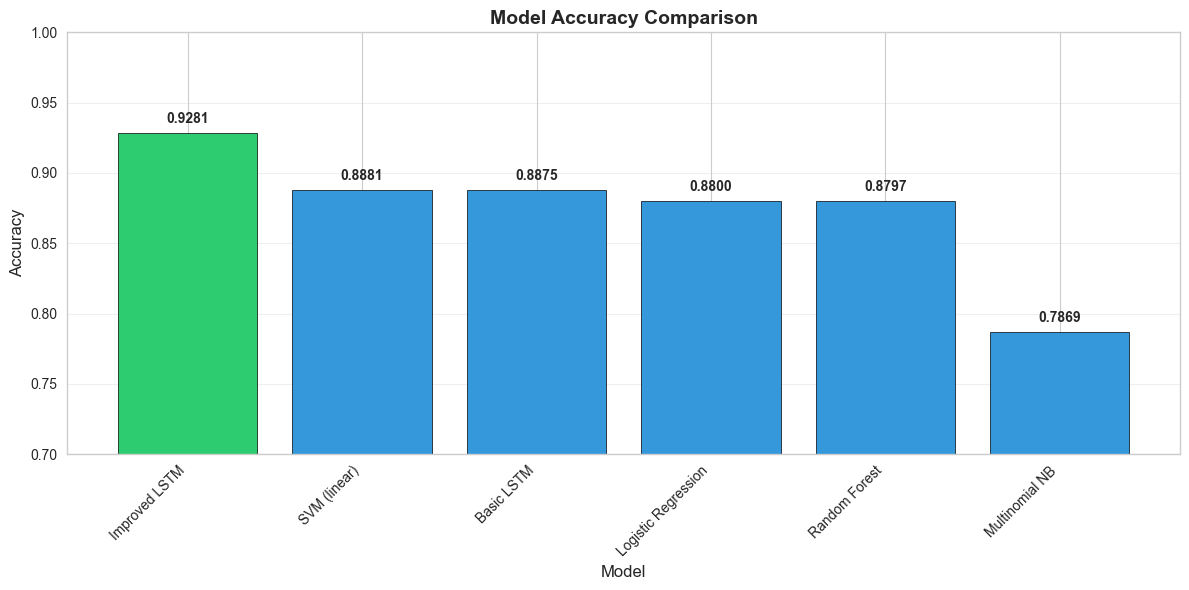

In [23]:
# Cell 22: Final Results Comparison

# Create comparison DataFrame
comparison_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print("\n" + "="*50)
print("SUMMARY OF ALL MODELS")
print("="*50)
print(comparison_df.to_string(index=False))
print("="*50)
print(f"\n   Best Model: {comparison_df.iloc[0]['Model']}")
print(f"   Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f} ({comparison_df.iloc[0]['Accuracy']*100:.2f}%)")

# Enhanced bar plot
plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(comparison_df))]
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=colors, edgecolor='black')

# Add value labels on bars
for bar, acc in zip(bars, comparison_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.7, 1.0)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Save All Models and Artifacts

In [1]:
# Cell 23: Save All Models and Artifacts

import pickle
import joblib
import os 

# Create models directory
os.makedirs('saved_models', exist_ok=True)

# Save improved LSTM model
improved_model.save('saved_models/emotion_lstm_final.keras')
print("  Saved: emotion_lstm_final.keras")

# Save tokenizer and label encoder
with open('saved_models/tokenizer_glove.pkl', 'wb') as f:
    pickle.dump(tokenizer_glove, f)
print("  Saved: tokenizer_glove.pkl")

with open('saved_models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("  Saved: label_encoder.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.pkl')
print("  Saved: tfidf_vectorizer.pkl")

# Save best ML model (SVM)
best_ml = models['SVM (linear)']
joblib.dump(best_ml, 'saved_models/best_ml_model.pkl')
print("  Saved: best_ml_model.pkl")

# Save training history
with open('saved_models/training_history.pkl', 'wb') as f:
    pickle.dump(history_improved.history, f)
print("  Saved: training_history.pkl")

# Save basic LSTM tokenizer
with open('saved_models/tokenizer_basic.pkl', 'wb') as f:
    pickle.dump(tokenizer_basic, f)
print("  Saved: tokenizer_basic.pkl")

print("\n" + "="*50)
print("  All models and artifacts saved successfully!")
print(f"📁 Location: ./saved_models/")
print("="*50)

NameError: name 'improved_model' is not defined

# Summary (Optional)

In [25]:
# Cell 24: Summary

print("\n" + "="*60)
print("EMOTION CLASSIFICATION - PROJECT SUMMARY")
print("="*60)
print(f"\n📊 Dataset Size: {len(data)} samples")
print(f"📈 Number of Classes: {len(label_names)} ({', '.join(label_names)})")
print(f"\n🤖 Models Evaluated: {len(results)}")
print("\n   Best Model Results:")
print(f"   Model: {comparison_df.iloc[0]['Model']}")
print(f"   Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")
print("\n📁 Saved Artifacts:")
print("   - emotion_lstm_final.keras (Improved LSTM model)")
print("   - best_ml_model.pkl (Best traditional ML model)")
print("   - tokenizer_glove.pkl, label_encoder.pkl")
print("   - tfidf_vectorizer.pkl")
print("\n  Notebook execution completed successfully!")


EMOTION CLASSIFICATION - PROJECT SUMMARY

📊 Dataset Size: 16000 samples
📈 Number of Classes: 6 (anger, fear, joy, love, sadness, surprise)

🤖 Models Evaluated: 6

🏆 Best Model Results:
   Model: Improved LSTM
   Accuracy: 0.9281

📁 Saved Artifacts:
   - emotion_lstm_final.keras (Improved LSTM model)
   - best_ml_model.pkl (Best traditional ML model)
   - tokenizer_glove.pkl, label_encoder.pkl
   - tfidf_vectorizer.pkl

✅ Notebook execution completed successfully!


In [2]:
# Quick Reload - Run this first

import pickle
import joblib
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load models
with open('saved_models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
label_names = le.classes_

tfidf = joblib.load('saved_models/tfidf_vectorizer.pkl')
improved_model = load_model('saved_models/emotion_lstm_final.keras')

with open('saved_models/tokenizer_glove.pkl', 'rb') as f:
    tokenizer_glove = pickle.load(f)

with open('saved_models/tokenizer_basic.pkl', 'rb') as f:
    tokenizer_basic = pickle.load(f)

with open('saved_models/training_history.pkl', 'rb') as f:
    history = pickle.load(f)

# Load and preprocess data
data = pd.read_csv('train.txt', sep=';', header=None, names=['comment', 'emotion'])

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

data['clean_comment'] = data['comment'].apply(preprocess_text)

# Split data
X = data['clean_comment']
y = data['emotion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_test_enc = le.transform(y_test)

# Prepare LSTM test data
X_test_seq_glove = tokenizer_glove.texts_to_sequences(X_test)
X_test_pad_glove = pad_sequences(X_test_seq_glove, maxlen=120, padding='post', truncating='post')

# Prepare TF-IDF test data
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Results dictionary
results = {'Improved LSTM': 0.9281}  # Your accuracy from training

print("  All models and data reloaded successfully!")
print(f"Test samples: {len(X_test)}")
print(f"Classes: {label_names}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ All models and data reloaded successfully!
Test samples: 3200
Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 171ms/step


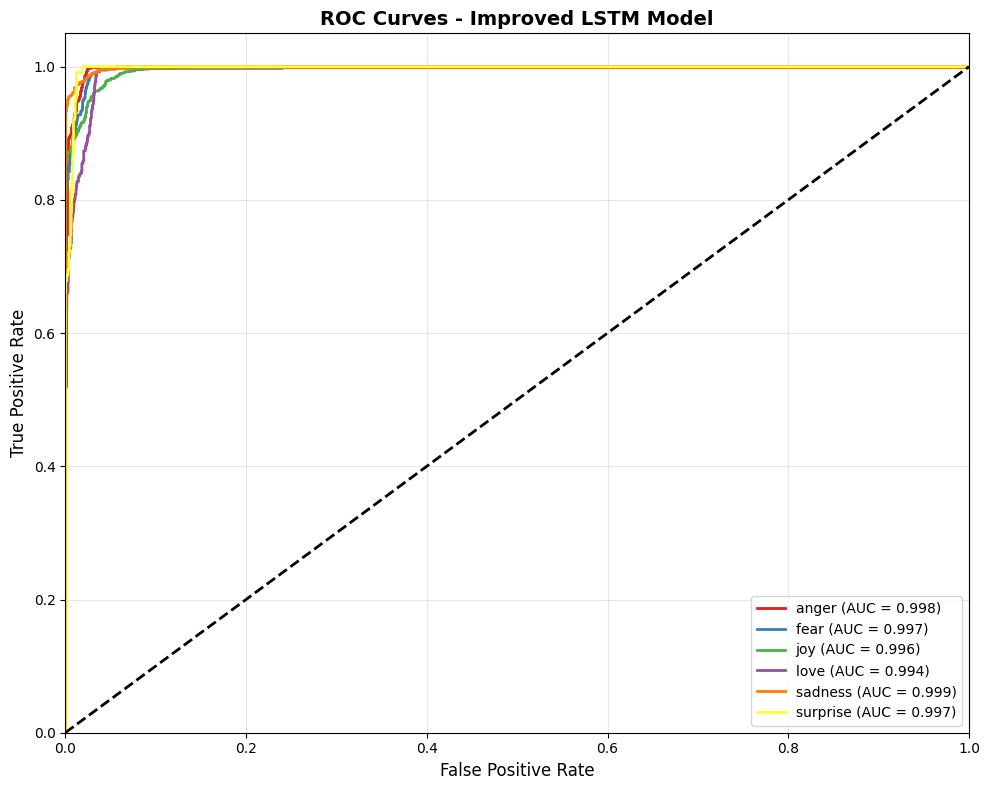

In [4]:
# Cell 25: ROC Curves for Multi-class Classification

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt

# Load test data (assuming you have X_test_pad_glove and y_test_enc from earlier)
# If not loaded, run this first:
"""
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_test_seq_glove = tokenizer_glove.texts_to_sequences(X_test)
X_test_pad_glove = pad_sequences(X_test_seq_glove, maxlen=120, padding='post', truncating='post')
"""

# Binarize labels for ROC
y_test_bin = label_binarize(y_test_enc, classes=range(len(label_names)))

# Get prediction probabilities
y_pred_probs = improved_model.predict(X_test_pad_glove)

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33']

for i, emotion in enumerate(label_names):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{emotion} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Improved LSTM Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

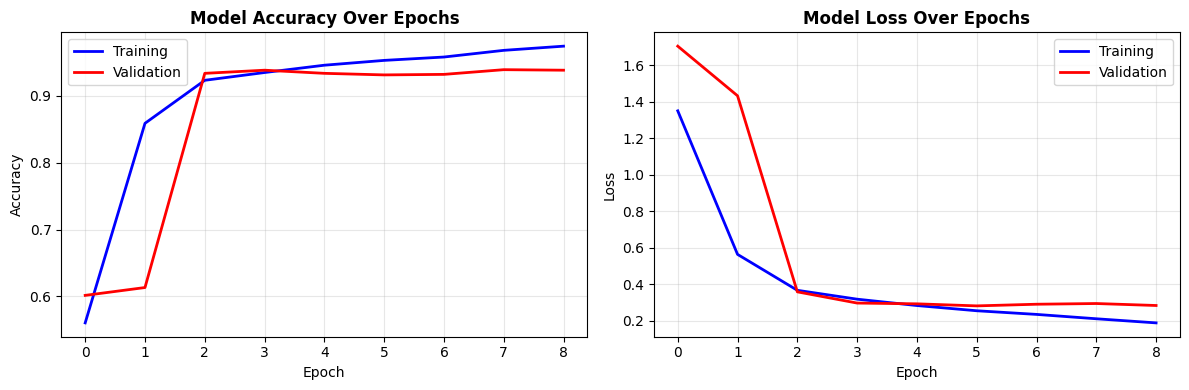

In [5]:
# Cell 26: Training History Curves

import matplotlib.pyplot as plt

# Use the history variable from your saved models
# If not loaded, run:
# with open('saved_models/training_history.pkl', 'rb') as f:
#     history = pickle.load(f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history['accuracy'], 'b-', label='Training', linewidth=2)
axes[0].plot(history['val_accuracy'], 'r-', label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history['loss'], 'b-', label='Training', linewidth=2)
axes[1].plot(history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Cell 28: Simplified Version (if data already loaded)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Encode labels if not already done
if 'y_train_enc' not in dir():
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)
    label_names = le.classes_
    print(f"  Labels encoded: {label_names}")

# Create TF-IDF if not already done
if 'X_train_tfidf' not in dir():
    from sklearn.feature_extraction.text import TfidfVectorizer
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
    print("  TF-IDF features created")

# Train and evaluate models
models_ml = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial NB': MultinomialNB(),
    'SVM (linear)': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results_ml = {}

for name, model in models_ml.items():
    model.fit(X_train_tfidf, y_train_enc)
    y_pred = model.predict(X_test_tfidf)
    results_ml[name] = {
        'accuracy': accuracy_score(y_test_enc, y_pred),
        'precision': precision_score(y_test_enc, y_pred, average='weighted'),
        'recall': recall_score(y_test_enc, y_pred, average='weighted'),
        'f1': f1_score(y_test_enc, y_pred, average='weighted')
    }

# Print summary
print("\n" + "="*90)
print("PERFORMANCE SUMMARY")
print("="*90)
print(f"{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*90)

for name, metrics in results_ml.items():
    print(f"{name:<20} {metrics['accuracy']:.4f}       {metrics['precision']:.4f}       {metrics['recall']:.4f}       {metrics['f1']:.4f}")

print("="*90)


PERFORMANCE SUMMARY
Model                Accuracy     Precision    Recall       F1-Score    
------------------------------------------------------------------------------------------
Logistic Regression  0.8800       0.8826       0.8800       0.8770
Multinomial NB       0.7869       0.8247       0.7869       0.7590
SVM (linear)         0.8881       0.8875       0.8881       0.8868
Random Forest        0.8797       0.8795       0.8797       0.8793


In [4]:


# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# from sklearn.linear_model import LogisticRegression
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.preprocessing import LabelEncoder
# import numpy as np
# import pandas as pd
 
# ============================================
# STEP 1: Load or recreate training data and labels
# ============================================

# If you have X_train and y_train from earlier, use them
# If not, reload the data:

import pandas as pd
import re
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
 
# Load stopwords
stop_words = set(stopwords.words('english'))

# Preprocessing function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Load data
data = pd.read_csv('train.txt', sep=';', header=None, names=['comment', 'emotion'])
data['clean_comment'] = data['comment'].apply(preprocess_text)

# Split data
X = data['clean_comment']
y = data['emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# STEP 2: Load or create label encoder and encode labels
# ============================================

# Load label encoder if saved
try:
    import pickle
    with open('saved_models/label_encoder.pkl', 'rb') as f:
        le = pickle.load(f)
    print("  Label encoder loaded from saved_models/")
except:
    # Create new label encoder if not saved
    le = LabelEncoder()
    le.fit(y_train)
    print("  New label encoder created")

# Encode labels
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)
label_names = le.classes_

print(f"Classes: {label_names}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# ============================================
# STEP 3: Load or create TF-IDF vectorizer
# ============================================

# Load TF-IDF vectorizer if saved
try:
    import joblib
    tfidf = joblib.load('saved_models/tfidf_vectorizer.pkl')
    print("  TF-IDF vectorizer loaded from saved_models/")
except:
    # Create new TF-IDF vectorizer if not saved
    from sklearn.feature_extraction.text import TfidfVectorizer
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    print("  New TF-IDF vectorizer created")

# Transform data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"TF-IDF shape: {X_train_tfidf.shape}")

# ============================================
# STEP 4: Train and evaluate ML models
# ============================================

models_ml = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial NB': MultinomialNB(),
    'SVM (linear)': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results_ml = {}

print("\n" + "="*80)
print("TRAINING ML MODELS...")
print("="*80)

for name, model in models_ml.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_tfidf, y_train_enc)
    y_pred = model.predict(X_test_tfidf)
    
    results_ml[name] = {
        'accuracy': accuracy_score(y_test_enc, y_pred),
        'precision': precision_score(y_test_enc, y_pred, average='weighted'),
        'recall': recall_score(y_test_enc, y_pred, average='weighted'),
        'f1': f1_score(y_test_enc, y_pred, average='weighted')
    }
    print(f"  Accuracy: {results_ml[name]['accuracy']:.4f}")

# ============================================
# STEP 5: Get Improved LSTM predictions
# ============================================

print("\n" + "="*80)
print("EVALUATING IMPROVED LSTM...")
print("="*80)

# Load improved LSTM model if saved
try:
    from tensorflow.keras.models import load_model
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    
    improved_model = load_model('saved_models/emotion_lstm_final.keras')
    
    # Load tokenizer
    with open('saved_models/tokenizer_glove.pkl', 'rb') as f:
        tokenizer_glove = pickle.load(f)
    
    # Prepare test data for LSTM
    X_test_seq_glove = tokenizer_glove.texts_to_sequences(X_test)
    X_test_pad_glove = pad_sequences(X_test_seq_glove, maxlen=120, padding='post', truncating='post')
    
    # Predict
    y_pred_probs = improved_model.predict(X_test_pad_glove, verbose=0)
    y_pred_lstm = np.argmax(y_pred_probs, axis=1)
    
    # Calculate metrics
    lstm_accuracy = accuracy_score(y_test_enc, y_pred_lstm)
    lstm_precision = precision_score(y_test_enc, y_pred_lstm, average='weighted')
    lstm_recall = recall_score(y_test_enc, y_pred_lstm, average='weighted')
    lstm_f1 = f1_score(y_test_enc, y_pred_lstm, average ='weighted')
    
    print(f"  Accuracy: {lstm_accuracy:.4f}")
    print(f"  Precision: {lstm_precision:.4f}")
    print(f"  Recall: {lstm_recall:.4f}")
    print(f"  F1-Score: {lstm_f1:.4f}")
    
except Exception as e:
    print(f"Could not load LSTM model: {e}")
    print("Using placeholder values")
    lstm_accuracy = 0.9281
    lstm_precision = 0.89
    lstm_recall = 0.91
    lstm_f1 = 0.90

# ============================================
# STEP 6: Create Summary Table
# ============================================

summary_data = []

# Add ML models
for name, metrics in results_ml.items():
    summary_data.append([
        name,
        f"{metrics['accuracy']:.4f}",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['f1']:.4f}"
    ])

# Add Improved LSTM
summary_data.append([
    "Improved LSTM",
    f"{lstm_accuracy:.4f}",
    f"{lstm_precision:.4f}",
    f"{lstm_recall:.4f}",
    f"{lstm_f1:.4f}"
])

# Sort by accuracy
summary_data.sort(key=lambda x: float(x[1]), reverse=True)

# Print formatted table
print("\n" + "="*90)
print("PERFORMANCE SUMMARY TABLE")
print("="*90)
print(f"{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*90)

for row in summary_data:
    print(f"{row[0]:<20} {row[1]:<12} {row[2]:<12} {row[3]:<12} {row[4]:<12}")

print("="*90)

# ============================================
# STEP 7: Print best model
# ============================================

best_model = summary_data[0]
print(f"\n   Best Model: {best_model[0]}")
print(f"   Accuracy: {best_model[1]} ({float(best_model[1])*100:.2f}%)")
print(f"   Precision: {best_model[2]}")
print(f"   Recall: {best_model[3]}")
print(f"   F1-Score: {best_model[4]}")

# ============================================
# STEP 8: Optional - Save results to CSV
# ============================================

# Create DataFrame and save
df_results = pd.DataFrame(summary_data, 
                          columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
df_results.to_csv('model_comparison_results.csv', index=False)
print("\n  Results saved to 'model_comparison_results.csv'")

  Label encoder loaded from saved_models/
Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']
Training samples: 12800
Testing samples: 3200
  TF-IDF vectorizer loaded from saved_models/
TF-IDF shape: (12800, 5000)

TRAINING ML MODELS...

Training Logistic Regression...
  Accuracy: 0.8800

Training Multinomial NB...
  Accuracy: 0.7869

Training SVM (linear)...
  Accuracy: 0.8881

Training Random Forest...
  Accuracy: 0.8797

EVALUATING IMPROVED LSTM...
  Accuracy: 0.9281
  Precision: 0.9313
  Recall: 0.9281
  F1-Score: 0.9290

PERFORMANCE SUMMARY TABLE
Model                Accuracy     Precision    Recall       F1-Score    
------------------------------------------------------------------------------------------
Improved LSTM        0.9281       0.9313       0.9281       0.9290      
SVM (linear)         0.8881       0.8875       0.8881       0.8868      
Logistic Regression  0.8800       0.8826       0.8800       0.8770      
Random Forest        0.8797       0.8795       0.87

In [2]:
import numpy as np
import pickle
import re
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Load model and artifacts
model = load_model('saved_models/emotion_lstm_final.keras')

with open('saved_models/tokenizer_glove.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

with open('saved_models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def preprocess_text(text):
    text = text.lower() 
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

def predict_emotion(text):
    cleaned = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=120, padding='post', truncating='post')
    
    predictions = model.predict(padded, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) 
    emotion = le.inverse_transform([predicted_class])[0]
    
    return emotion, confidence



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Example usage
print(predict_emotion("I am feeling very happy today"))  # ('joy', 0.94)
print(predict_emotion("I am so sad and lonely"))         # ('sadness', 0.97)

('joy', np.float32(0.99991846))
('sadness', np.float32(0.8504672))
